Notebook for analysis of experimental results for number of perturbation directions `P`.

`./scripts/runpexp` was ran with 3 different seeds beforehand.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
from pathlib import Path

project_root = Path.cwd()
if not (project_root / "runs").exists():
    project_root = project_root.parent

experiments = ["experiment_p_20260527_222827", "experiment_p_20260527_223212", "experiment_p_20260527_223216"]

EXPERIMENT_DIRS = [project_root / "runs" / exp for exp in experiments]

# list of all subdirectories, instead of the logs
experiments = []
for exp_dir in EXPERIMENT_DIRS:
    for subdir in exp_dir.iterdir():
        if subdir.is_dir() and not subdir.name.startswith("logs"):
            experiments.append(str(subdir.relative_to(project_root)))

experiments


['runs\\experiment_p_20260527_222827\\dd_cnn_fashionmnist_P1_20260527_222957_seed42',
 'runs\\experiment_p_20260527_222827\\dd_cnn_fashionmnist_P2_20260527_224619_seed42',
 'runs\\experiment_p_20260527_222827\\dd_cnn_fashionmnist_P4_20260527_231127_seed42',
 'runs\\experiment_p_20260527_222827\\dd_cnn_fashionmnist_P8_20260527_235546_seed42',
 'runs\\experiment_p_20260527_222827\\dd_mlp_fashionmnist_P1_20260528_011316_seed42',
 'runs\\experiment_p_20260527_222827\\dd_mlp_fashionmnist_P2_20260528_012304_seed42',
 'runs\\experiment_p_20260527_222827\\dd_mlp_fashionmnist_P4_20260528_013359_seed42',
 'runs\\experiment_p_20260527_222827\\dd_mlp_fashionmnist_P8_20260528_014434_seed42',
 'runs\\experiment_p_20260527_223212\\dd_cnn_fashionmnist_P1_20260528_015740_seed123',
 'runs\\experiment_p_20260527_223212\\dd_cnn_fashionmnist_P2_20260528_021344_seed123',
 'runs\\experiment_p_20260527_223212\\dd_cnn_fashionmnist_P4_20260528_023856_seed123',
 'runs\\experiment_p_20260527_223212\\dd_cnn_fashio

In [5]:
results = [str((project_root / "results" / e.split("\\")[2]).relative_to(project_root)) + ".json" for e in experiments]
results

['results\\dd_cnn_fashionmnist_P1_20260527_222957_seed42.json',
 'results\\dd_cnn_fashionmnist_P2_20260527_224619_seed42.json',
 'results\\dd_cnn_fashionmnist_P4_20260527_231127_seed42.json',
 'results\\dd_cnn_fashionmnist_P8_20260527_235546_seed42.json',
 'results\\dd_mlp_fashionmnist_P1_20260528_011316_seed42.json',
 'results\\dd_mlp_fashionmnist_P2_20260528_012304_seed42.json',
 'results\\dd_mlp_fashionmnist_P4_20260528_013359_seed42.json',
 'results\\dd_mlp_fashionmnist_P8_20260528_014434_seed42.json',
 'results\\dd_cnn_fashionmnist_P1_20260528_015740_seed123.json',
 'results\\dd_cnn_fashionmnist_P2_20260528_021344_seed123.json',
 'results\\dd_cnn_fashionmnist_P4_20260528_023856_seed123.json',
 'results\\dd_cnn_fashionmnist_P8_20260528_032145_seed123.json',
 'results\\dd_mlp_fashionmnist_P1_20260528_043852_seed123.json',
 'results\\dd_mlp_fashionmnist_P2_20260528_044738_seed123.json',
 'results\\dd_mlp_fashionmnist_P4_20260528_045634_seed123.json',
 'results\\dd_mlp_fashionmnist_P8

In [6]:
from tbparse import SummaryReader
from typing import List, Dict

raw_dfs: List[pd.DataFrame] = [
    SummaryReader(exp_dir, extra_columns={'wall_time', 'dir_name'}).scalars 
    for exp_dir in EXPERIMENT_DIRS
]
df_all = pd.concat(raw_dfs, ignore_index=True)

df_all = df_all.assign(
    wall_clock=pd.to_datetime(df_all['wall_time'], unit='s', utc=True),
    architecture=df_all['dir_name'].str.extract(r'_(cnn|mlp)_')[0],
    num_perturbations=df_all['dir_name'].str.extract(r'_P(\d+)_')[0].astype(int),
    seed=df_all['dir_name'].str.extract(r'_seed(\d+)')[0].astype(int),
).drop(columns=['wall_time', 'dir_name'])

arch_dfs: Dict[str, pd.DataFrame] = {
    arch: sub_df.drop(columns=['architecture']).reset_index(drop=True)
    for arch, sub_df in df_all.groupby('architecture')
}

df_mlp, df_cnn = arch_dfs['mlp'], arch_dfs['cnn']

In [7]:
# architectures per dataset used for FashionMNIST 
MLP_LAYERS = 3
CNN_LAYERS = 2

# HELPER FUNCTIONS
def aggregate_over_seeds(df: pd.DataFrame) -> pd.DataFrame:
    """For each (tag, num_perturbations, step), compute mean and std across seeds."""
    return (
        df.groupby(['tag', 'num_perturbations', 'step'])['value']
          .agg(mean='mean', std='std')
          .reset_index()
    )

def plot_tags(agg: pd.DataFrame, tags: list, arch_name: str):
    p_values = sorted(agg['num_perturbations'].unique())
    fig, axes = plt.subplots(1, len(tags), figsize=(5 * len(tags), 4), squeeze=False)

    for i, tag in enumerate(tags):
        ax = axes[0][i]
        for p in p_values:
            sub = agg[(agg['tag'] == tag) & (agg['num_perturbations'] == p)].sort_values('step')
            ax.plot(sub['step'], sub['mean'], label=f'P={p}')
            ax.fill_between(sub['step'], sub['mean'] - sub['std'], sub['mean'] + sub['std'], alpha=0.2)
        ax.set_title(tag.replace('dd/', ''), fontsize=9)
        ax.set_xlabel('Step')
        ax.set_ylabel('mean +- std')
        ax.legend(fontsize=7)

    fig.suptitle(arch_name.upper(), fontsize=12)
    plt.tight_layout()
    plt.show()


## MLP


In [8]:
print(df_mlp.columns)
df_mlp.iloc[[0,10,100,500,10000]]

Index(['step', 'tag', 'value', 'wall_clock', 'num_perturbations', 'seed'], dtype='str')


,step,tag,value,wall_clock,num_perturbations,seed
0,1,dd/layer_acc/layer_0/train,0.483019,2026-05-27 23:13:28.572355509+00:00,1,42
10,11,dd/layer_acc/layer_0/train,0.753741,2026-05-27 23:13:51.674582481+00:00,1,42
100,101,dd/layer_acc/layer_0/train,0.803704,2026-05-27 23:17:26.327007294+00:00,1,42
500,101,dd/layer_acc/layer_1/train,0.762389,2026-05-27 23:17:26.327136040+00:00,1,42
10000,1,dd/layer_loss/layer_2/train,2.327796,2026-05-27 23:34:08.988227367+00:00,4,42


In [9]:
mlp_agg = aggregate_over_seeds(df_mlp)
mlp_agg.head()

,tag,num_perturbations,step,mean,std
0,dd/layer_acc/layer_0/train,1,1,0.455012,0.025330
1,dd/layer_acc/layer_0/train,1,2,0.644117,0.003553
2,dd/layer_acc/layer_0/train,1,3,0.687488,0.007062
3,dd/layer_acc/layer_0/train,1,4,0.711204,0.006605
4,dd/layer_acc/layer_0/train,1,5,0.726698,0.008172


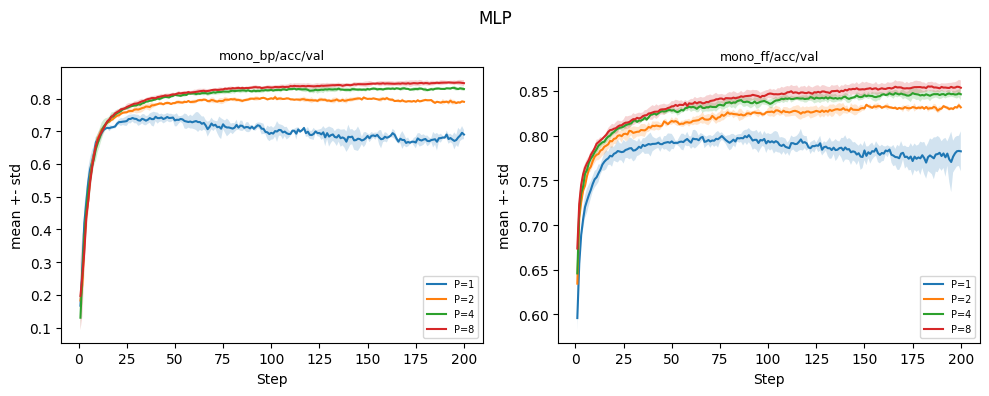

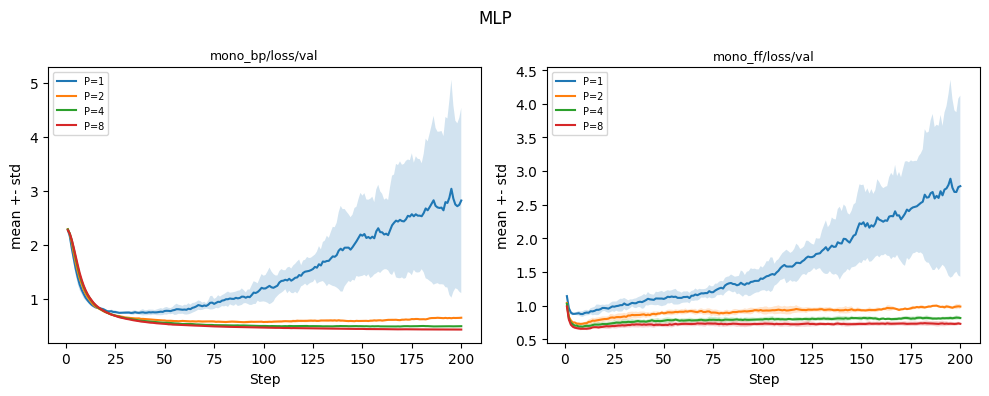

In [10]:
plot_tags(mlp_agg, ['dd/mono_bp/acc/val', 'dd/mono_ff/acc/val'], 'mlp')
plot_tags(mlp_agg, ['dd/mono_bp/loss/val', 'dd/mono_ff/loss/val'], 'mlp')

#### Test Result table


In [16]:
from pathlib import Path

def parse_result(res_path: str) -> tuple[str, int]:
    stem = Path(res_path).stem
    parts = stem.split('_')
    num_perturbations = int(parts[3].removeprefix('P'))
    seed = int(parts[-1].removeprefix('seed'))
    return num_perturbations, seed

res_dfs = []
mlp_results = filter(lambda res : "_mlp_" in res ,results)

for res in mlp_results:
    res_df = pd.read_json(project_root / res)
    num_perturbations, seed = parse_result(res)
    res_df = res_df.assign(
        num_perturbations=num_perturbations,
        seed=seed,
    )

    # drop best epoch rows and early stopping columns
    res_df.drop(columns=['early_stopping'], inplace=True)
    res_df.drop(['best_epoch', 'stopped_epoch'], axis=0, inplace=True)

    res_dfs.append(res_df)

res_df = pd.concat(res_dfs, ignore_index=True)
res_df.head()


,mono_ff,mono_bp,num_perturbations,seed
0,0.7829,0.6783,1,42
1,0.8242,0.7825,2,42
2,0.8347,0.8208,4,42
3,0.8465,0.8385,8,42
4,0.7975,0.7048,1,123


In [22]:
res_agg = (
    res_df.groupby("num_perturbations")[["mono_ff", "mono_bp"]]
    .agg(["mean", "std"])
)

res_agg.columns = [f"{col}_{stat}" for col, stat in res_agg.columns]
print(res_agg)

                   mono_ff_mean  mono_ff_std  mono_bp_mean  mono_bp_std
num_perturbations                                                      
1                      0.774333     0.028435      0.681900     0.021329
2                      0.823833     0.002669      0.781867     0.004881
4                      0.837533     0.002454      0.820867     0.000603
8                      0.845267     0.002401      0.839233     0.001537


## CNN


In [23]:
cnn_agg = aggregate_over_seeds(df_cnn)
cnn_agg.head()

,tag,num_perturbations,step,mean,std
0,dd/layer_acc/layer_0/train,1,1,0.199809,0.009278
1,dd/layer_acc/layer_0/train,1,2,0.343883,0.012552
2,dd/layer_acc/layer_0/train,1,3,0.444049,0.013983
3,dd/layer_acc/layer_0/train,1,4,0.503099,0.007117
4,dd/layer_acc/layer_0/train,1,5,0.544296,0.006909


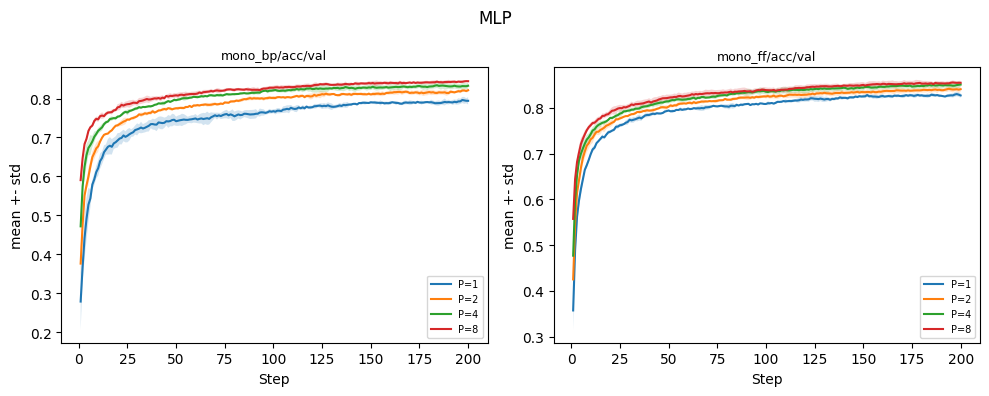

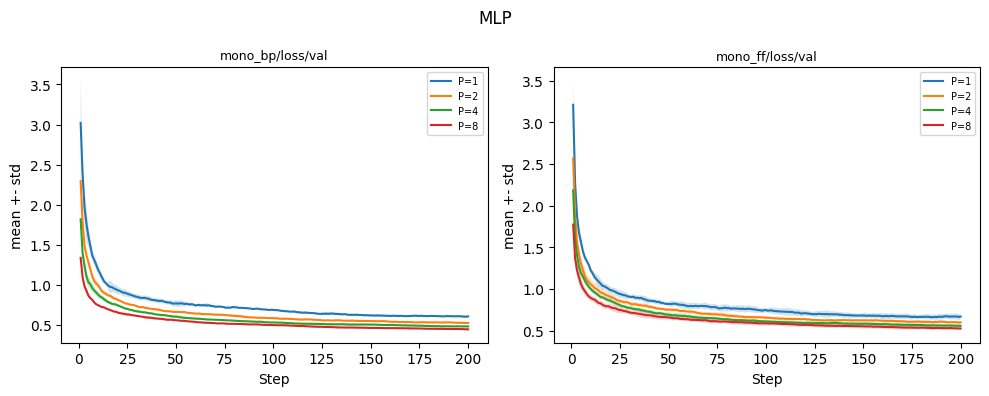

In [24]:
plot_tags(cnn_agg, ['dd/mono_bp/acc/val', 'dd/mono_ff/acc/val'], 'mlp')
plot_tags(cnn_agg, ['dd/mono_bp/loss/val', 'dd/mono_ff/loss/val'], 'mlp')

In [25]:
res_dfs = []
cnn_results = filter(lambda res : "_cnn_" in res ,results)

for res in cnn_results:
    res_df = pd.read_json(project_root / res)
    num_perturbations, seed = parse_result(res)
    res_df = res_df.assign(
        num_perturbations=num_perturbations,
        seed=seed,
    )

    # drop best epoch rows and early stopping columns
    res_df.drop(columns=['early_stopping'], inplace=True)
    res_df.drop(['best_epoch', 'stopped_epoch'], axis=0, inplace=True)

    res_dfs.append(res_df)

res_df = pd.concat(res_dfs, ignore_index=True)
res_df.head()


,mono_ff,mono_bp,num_perturbations,seed
0,0.8198,0.7916,1,42
1,0.8319,0.8104,2,42
2,0.8439,0.8268,4,42
3,0.8461,0.8331,8,42
4,0.8197,0.7829,1,123


In [26]:
res_agg = (
    res_df.groupby("num_perturbations")[["mono_ff", "mono_bp"]]
    .agg(["mean", "std"])
)

res_agg.columns = [f"{col}_{stat}" for col, stat in res_agg.columns]
print(res_agg)

                   mono_ff_mean  mono_ff_std  mono_bp_mean  mono_bp_std
num_perturbations                                                      
1                      0.820400     0.001127      0.789000     0.005302
2                      0.833233     0.001595      0.811267     0.002136
4                      0.841067     0.003837      0.827400     0.003637
8                      0.846933     0.000764      0.836067     0.002902
